In [140]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [141]:

device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [142]:
import pandas as pd 
df= pd.read_csv("ZEEL.NS_stock_data.csv")

In [143]:
df.shape

(5430, 8)

In [144]:
df.head()

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,2002-07-01,38.847958,39.138096,38.481468,38.878498,32.353092,4031528.0,ZEEL.NS
1,2002-07-02,38.725796,40.115402,38.542549,39.214447,32.632656,14152321.0,ZEEL.NS
2,2002-07-03,39.031200,39.764183,38.863228,39.565666,32.924931,8456844.0,ZEEL.NS
3,2002-07-04,39.871075,40.833111,39.306068,39.535126,32.899509,12745157.0,ZEEL.NS
4,2002-07-05,40.008511,40.008511,39.015930,39.351879,32.747009,6445895.0,ZEEL.NS


In [145]:
df.isnull().sum()

Unnamed: 0     0
open          10
high          10
low           10
close         10
adjclose      10
volume        10
ticker         0
dtype: int64

In [146]:
df=df.sort_values(df.columns[0]).reset_index(drop=True)

In [147]:
df1=df.iloc[:,1:-1]
df1.shape
df1.head()

,open,high,low,close,adjclose,volume
0,38.847958,39.138096,38.481468,38.878498,32.353092,4031528.0
1,38.725796,40.115402,38.542549,39.214447,32.632656,14152321.0
2,39.031200,39.764183,38.863228,39.565666,32.924931,8456844.0
3,39.871075,40.833111,39.306068,39.535126,32.899509,12745157.0
4,40.008511,40.008511,39.015930,39.351879,32.747009,6445895.0


In [148]:
df1.isnull().sum()

open        10
high        10
low         10
close       10
adjclose    10
volume      10
dtype: int64

In [149]:
df1=df1.interpolate(method="linear", limit_direction="both")
df1.isnull().sum()

open        0
high        0
low         0
close       0
adjclose    0
volume      0
dtype: int64

In [150]:
f_name=df1.columns

print(f_name)

Index(['open', 'high', 'low', 'close', 'adjclose', 'volume'], dtype='str')


<function matplotlib.pyplot.show(close=None, block=None)>

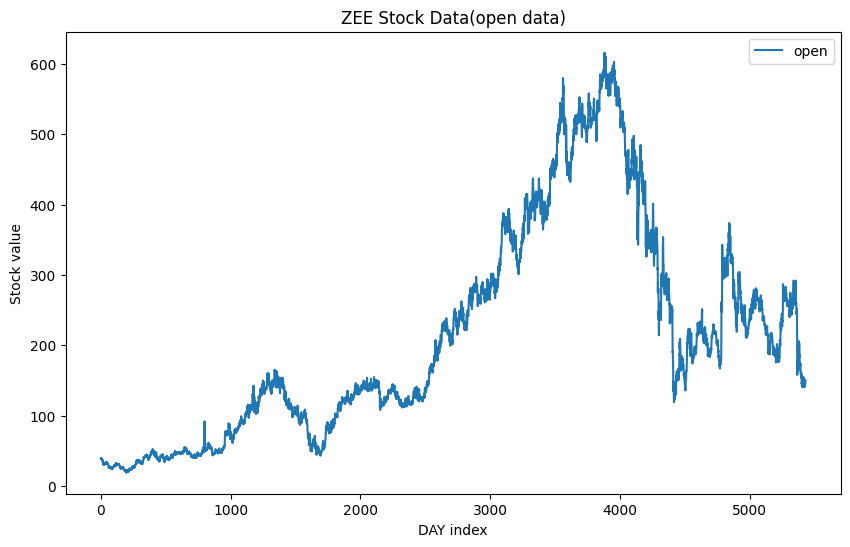

In [151]:
plt.figure(figsize=(10,6))
plt.plot(df1.index, df1[f_name[0]], label=f_name[0])
plt.title('ZEE Stock Data(open data)')
plt.xlabel('DAY index')
plt.ylabel('Stock value')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

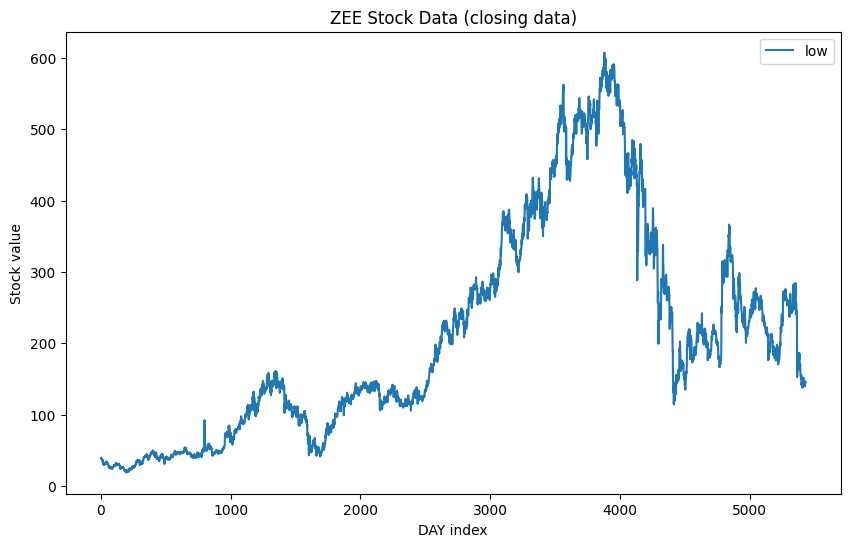

In [152]:
plt.figure(figsize=(10,6))
plt.plot(df1.index, df1[f_name[2]], label=f_name[2])
plt.title('ZEE Stock Data (closing data)')
plt.xlabel('DAY index')
plt.ylabel('Stock value')
plt.legend()
plt.show

In [153]:
data=df1.values.astype(np.float32)
print(data.shape)

(5430, 6)


In [154]:
input_step=10
output_step=5
train_ratio=0.8
batch_size=4

In [155]:
len(data)

5430

In [156]:
split_idx=int(len(data)*train_ratio)
print(split_idx)

4344


In [157]:
train_data1=data[:split_idx]
test_data=data[split_idx:]

In [158]:
split_idx2=int(len(train_data1)*0.8)

In [159]:
train_data=train_data1[:split_idx2]
val_data=train_data1[split_idx2:]


In [160]:
train_data.shape

(3475, 6)

In [161]:
test_data.shape

(1086, 6)

In [162]:
val_data.shape

(869, 6)

In [163]:
from sklearn.preprocessing import normalize
train_data_norm= normalize(train_data, norm='l2', axis=0)
test_data_norm=normalize(test_data, norm='l2', axis=0)
val_data_norm=normalize(val_data, norm='l2', axis=0)

In [164]:
def create_sequences(data_array, input_step=10, output_step=5, overlap=2):
    x,y=[],[]
    total_len=len(data_array)
    stride=input_step-overlap
    if stride<=0:
        raise ValueError("overlap must be smaller than input step")
    for i in range(0, total_len-input_step-output_step+1, stride):
        x.append(data_array[i:i+input_step])
        y.append(data_array[i+input_step: i+input_step+output_step])
    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)

In [165]:
x_train, y_train= create_sequences(train_data_norm, input_step,output_step, overlap=2)
x_test, y_test=create_sequences(test_data_norm,input_step,output_step,overlap=8)
x_val, y_val=create_sequences(val_data_norm, input_step, output_step, overlap=8)

In [166]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

x_train: (433, 10, 6)
y_train: (433, 5, 6)
x_test: (536, 10, 6)
y_test: (536, 5, 6)
x_val: (428, 10, 6)
y_val: (428, 5, 6)


In [167]:
class TimeSeriesDataset(Dataset):
    def __init__(self,x,y):
        self.x=torch.tensor(x,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index], self.y[index]


In [168]:
train_dataset=TimeSeriesDataset(x_train,y_train)
test_dataset=TimeSeriesDataset(x_test, y_test)
val_dataset=TimeSeriesDataset(x_val,y_val)

train_loader=DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=4, shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=4, shuffle=True)

In [169]:
class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(6,10, batch_first=True)
        self.fc=nn.Linear(10,5*6)
    def forward(self,x):
        out,_=self.lstm(x)
        out=self.fc(out[:,-1,:])
        return out.view(-1,5,6)

In [170]:
model=LSTMForecaster().to(device)
lr=0.0001
optimizer= torch.optim.Adam(model.parameters(), lr=lr)
criterion=nn.MSELoss()
scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [171]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss=0.0
    for x_batch, y_batch in loader:
        x_batch=x_batch.to(device)
        y_batch=y_batch.to(device)

        optimizer.zero_grad()
        preds=model(x_batch)
        loss=criterion(preds,y_batch)
        loss.backward()
        optimizer.step()

        running_loss+= loss.item()*x_batch.size(0)
    return running_loss/len(loader.dataset)

In [172]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss=0.0
    all_preds=[]
    all_targets=[]

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch=x_batch.to(device)
            y_batch=y_batch.to(device)

            preds= model(x_batch)
            loss=criterion(preds,y_batch)
            running_loss+= loss.item()*x_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())
    avg_loss= running_loss/len(loader.dataset)
    all_preds= torch.cat(all_preds, dim=0).numpy()
    all_targets=torch.cat(all_targets, dim=0).numpy

    return avg_loss, all_preds, all_targets
 


In [173]:
EPOCH=100
patience=5
train_losses=[]
val_losses=[]
best_val_loss=float('inf')
epochs_no_improve=0
for epoch in range(EPOCH):
    train_loss=train_one_epoch(model,train_loader,optimizer,criterion,device)
    val_loss,_,_= evaluate(model, val_loader, criterion,device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch [{epoch+1}/{EPOCH}] | Tain Loss: {train_loss:.6f} | val Loss: {val_loss:.6f}")

    if val_loss<best_val_loss:
        best_val_loss=val_loss
        epochs_no_improve=0

        torch.save(model.state_dict(),"best_model.pt")
    else:
        epochs_no_improve+=1
    if epochs_no_improve>=patience:
        print(f"EArly stopping triggered at epoch {epoch+1}")
        break

Epoch [1/100] | Tain Loss: 0.026785 | val Loss: 0.023137
Epoch [2/100] | Tain Loss: 0.019519 | val Loss: 0.016460
Epoch [3/100] | Tain Loss: 0.013716 | val Loss: 0.011316
Epoch [4/100] | Tain Loss: 0.009412 | val Loss: 0.007663
Epoch [5/100] | Tain Loss: 0.006430 | val Loss: 0.005255
Epoch [6/100] | Tain Loss: 0.004400 | val Loss: 0.003613
Epoch [7/100] | Tain Loss: 0.002997 | val Loss: 0.002523
Epoch [8/100] | Tain Loss: 0.002013 | val Loss: 0.001762
Epoch [9/100] | Tain Loss: 0.001320 | val Loss: 0.001237
Epoch [10/100] | Tain Loss: 0.000840 | val Loss: 0.000891
Epoch [11/100] | Tain Loss: 0.000521 | val Loss: 0.000664
Epoch [12/100] | Tain Loss: 0.000325 | val Loss: 0.000556
Epoch [13/100] | Tain Loss: 0.000215 | val Loss: 0.000499
Epoch [14/100] | Tain Loss: 0.000159 | val Loss: 0.000499
Epoch [15/100] | Tain Loss: 0.000133 | val Loss: 0.000501
Epoch [16/100] | Tain Loss: 0.000123 | val Loss: 0.000479
Epoch [17/100] | Tain Loss: 0.000119 | val Loss: 0.000481
Epoch [18/100] | Tain L

In [174]:
test_loss,predictions, targets= evaluate(model, test_loader, criterion, device)
print("final test loss", test_loss)

final test loss 0.0003235380537438714


In [175]:
predictions.shape

(536, 5, 6)

In [176]:
predictions

array([[[0.01027346, 0.01120764, 0.01229793, 0.01125801, 0.01782498,
         0.01238826],
        [0.01371565, 0.01608257, 0.0132729 , 0.01846296, 0.01772226,
         0.01556796],
        [0.017817  , 0.01248252, 0.01680053, 0.01137432, 0.01473973,
         0.00796147],
        [0.01625502, 0.01293542, 0.00957285, 0.01684217, 0.01173153,
         0.01318833],
        [0.01303451, 0.01749761, 0.01235972, 0.01321086, 0.01646845,
         0.01144412]],

       [[0.00952163, 0.01033671, 0.01163571, 0.0091915 , 0.02018827,
         0.01349879],
        [0.01387227, 0.01694216, 0.01374657, 0.02127542, 0.01841951,
         0.01799332],
        [0.01953899, 0.01329263, 0.01909518, 0.01115252, 0.01482919,
         0.00748117],
        [0.01733559, 0.01341601, 0.00768514, 0.01783209, 0.01209613,
         0.01445502],
        [0.01305829, 0.01751286, 0.01253833, 0.01346073, 0.01626593,
         0.01253797]],

       [[0.01059088, 0.01049967, 0.01124281, 0.00789322, 0.01999092,
         0.013601

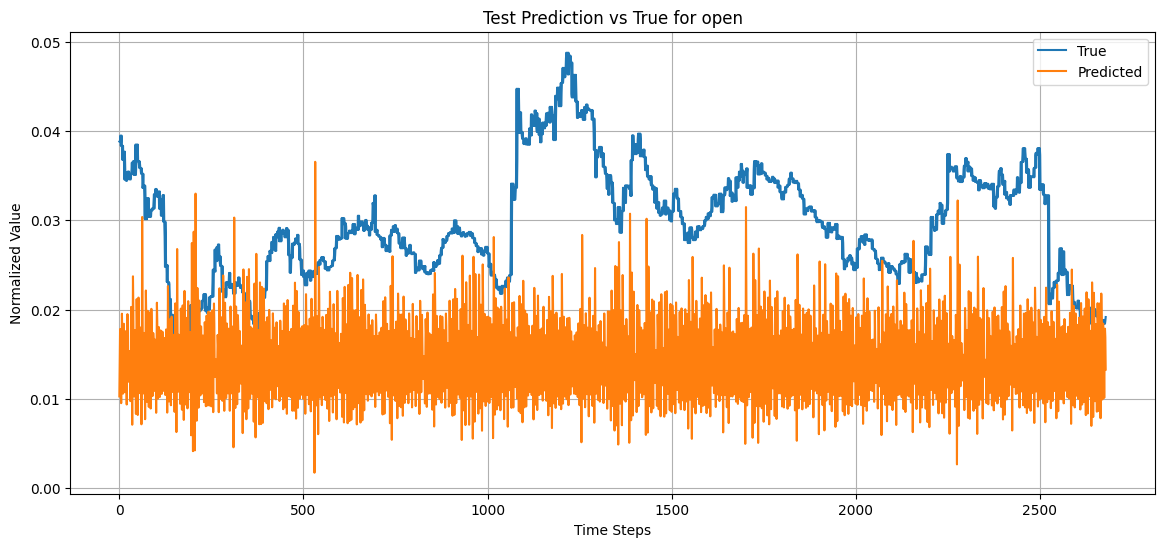

In [180]:
plot_ft = "open"

if plot_ft not in f_name:
    raise ValueError(f"{plot_ft} not found.")

feature_idx = f_name.get_loc(plot_ft)

# make sure targets is actual data
targets = y_test   # ✅ fix

pred_feature = predictions[:, :, feature_idx].reshape(-1)
true_feature = targets[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14,6))
plt.plot(true_feature, label="True")
plt.plot(pred_feature, label="Predicted")

plt.title(f"Test Prediction vs True for {plot_ft}")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Value")

plt.legend()
plt.grid(True)
plt.show()